In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sydneyndabai/glassdoor-interview/Glassdoor Interview.csv


# HireSignal - Decoding What Data Analyst Roles Really Demand

## Project Overview
This project investigates whether UK graduate Data Analyst job postings give 
candidates an accurate picture of what will actually be tested in interviews. 
Data is collected from two sources: the Adzuna API (287 job postings) and 
manually-collected Glassdoor interview reviews (42 reviews). The analysis 
reveals a significant "visibility gap" - skills like SQL appear far more 
often in interview processes than in job posting previews, meaning 
candidates often cannot assess the real technical bar before applying.

## Setup
Creating the folder structure for data storage and outputs.

In [10]:
import os

os.makedirs("/kaggle/working/data", exist_ok=True)
os.makedirs("/kaggle/working/outputs", exist_ok=True)

## Dependencies
Installing the required libraries for data collection.

In [11]:
!pip install requests

## API Configuration

Loading Adzuna API credentials for job data collection.

> **Note:** Replace `APP_ID` and `APP_KEY` with your own credentials from 
> [developer.adzuna.com](https://developer.adzuna.com) (free registration, 
> ~5 minutes). The data collection cells below (job postings and salary data) 
> require valid credentials to run - without them, these cells will return 
> an authentication error. Cleaned datasets are also provided in `/data` so 
> the analysis sections can be run independently of live API access.

In [12]:
APP_ID  = "5191aec0"
APP_KEY = "507b46a7567706f436a8dcf0e431b8a7"


## Data Collection - Job Postings
Collecting UK graduate data analyst job postings from the Adzuna API across 
eight search terms to maximise coverage. Results are deduplicated on title, 
company, and location to ensure each posting is unique.

In [13]:
import requests
import pandas as pd

search_terms = [
    "graduate data analyst",
    "junior data analyst",
    "entry level data analyst",
    "data analyst graduate",
    "analyst graduate scheme",
    "data graduate",
    "reporting analyst",
    "insights analyst"
]

all_jobs = []

for term in search_terms:
    for page in range(1, 11):
        url = "https://api.adzuna.com/v1/api/jobs/gb/search/" + str(page)
        
        params = {
            "app_id": APP_ID,
            "app_key": APP_KEY,
            "what": term,
            "where": "uk",
            "results_per_page": 50
        }
        
        response = requests.get(url, params=params)
        
        if response.status_code == 200:
            jobs = response.json()["results"]
            
            if len(jobs) == 0:
                break
                
            for job in jobs:
                all_jobs.append({
                    "title":       job.get("title", ""),
                    "company":     job.get("company", {}).get("display_name", ""),
                    "location":    job.get("location", {}).get("display_name", ""),
                    "description": job.get("description", ""),
                    "created":     job.get("created", "")
                })

df = pd.DataFrame(all_jobs)
df = df.drop_duplicates(subset=["title", "company", "location"])
df = df[df["description"] != ""]

print(f"Total unique job postings collected: {len(df)}")

Total unique job postings collected: 813


## Saving Raw Data
Saving the collected job postings to CSV for use in subsequent analysis steps.

In [14]:
df.to_csv("/kaggle/working/data/postings_raw.csv", index=False)

print(f"postings_raw.csv saved — {len(df)} rows, {len(df.columns)} columns")

postings_raw.csv saved — 813 rows, 5 columns


## Data Cleaning - Job Postings

The raw dataset (collected via the Adzuna API) is filtered and cleaned in a 
single reproducible step to produce the final analysis-ready dataset.

### Cleaning steps applied:
1. **Date filter** - retained postings from the last 6 months (from 24 Nov 2025) 
   to ensure findings reflect the current job market
2. **Title filter (whitelist)** - kept only titles containing approved Data 
   Analyst-related keywords (e.g. "data analyst", "insights analyst", 
   "business intelligence")
3. **Title filter (blacklist)** - removed titles containing disqualifying 
   keywords indicating adjacent but non-Data Analyst roles (e.g. "financial", 
   "regulatory", "payroll", "treasury", "HR", "risk")
4. **Missing values** - filled missing company names with "Unknown"
5. **Special characters** - removed non-ASCII characters from job descriptions
6. **Duplicates** - removed exact duplicates on title, company, and location
7. **Index reset** - reordered row numbers after filtering

### Result:
The combined whitelist + blacklist approach was necessary because many 
finance, HR, and risk roles (e.g. "Financial Reporting Analyst", "HR Data 
Analyst") contain Data Analyst-related keywords but represent a different 
job family with different skill requirements.
This cell both cleans and saves the dataset in one step to ensure the saved 
file always matches the cleaning logic shown above.

> **Note:** while this cleaned dataset is used for skill-frequency analysis 
> in the next section, the job description text itself has a known 
> limitation (API truncation at ~500 characters) - see the note at the 
> start of the Skill Frequency Analysis section and the full discussion 
> following the results table.

In [15]:
df = pd.read_csv("/kaggle/working/data/postings_raw.csv")
df["created"] = pd.to_datetime(df["created"], utc=True)
cutoff_date = pd.Timestamp("2025-11-24", tz="UTC")
df = df[df["created"] >= cutoff_date]

approved_keywords = [
    "data analyst", "data analysis", "data & insights", "data and insights",
    "insights analyst", "insight analyst", "reporting analyst", "bi analyst",
    "business intelligence", "business analyst", "analytics analyst",
    "data science", "data scientist", "junior analyst", "graduate analyst",
    "trainee analyst", "analyst trainee", "data trainee", "data graduate",
    "data cleansing", "data governance", "information analyst",
    "customer insight", "performance analyst", "technical analyst"
]

disqualifying_keywords = [
    "finance", "financial", "fp&a", "payroll", "regulatory",
    "reconciliation", "erp", "hr ", "human resources", "mandarin",
    "treasury", "tax", "credit", "risk", "audit", "actuarial",
    "compliance", "legal", "procurement", "supply chain",
    "senior data scientist", "data science manager", "principal",
    "successfactors", "workday"
]

def is_approved(title):
    t = title.lower()
    has_approved = any(k in t for k in approved_keywords)
    has_disqualifying = any(k in t for k in disqualifying_keywords)
    return has_approved and not has_disqualifying

df = df[df["title"].apply(is_approved)]
df["company"] = df["company"].fillna("Unknown")
df["description"] = df["description"].str.encode("ascii", "ignore").str.decode("ascii")
df = df.drop_duplicates(subset=["title", "company", "location"])
df = df.reset_index(drop=True)

print(f"Final clean rows: {len(df)}")
print(df["title"].value_counts().head(30))

df.to_csv("/kaggle/working/data/postings_clean.csv", index=False)
print("\nSaved to postings_clean.csv")

Final clean rows: 291
title
Data Analyst Trainee                                         53
Data Analyst                                                 21
Senior Data Analyst                                          13
Trainee Data Analyst                                         11
Senior Insight Analyst                                        9
Junior Data Analyst                                           8
Senior Data & Reporting Analyst                               7
Data & Insights Analyst                                       6
Data Science Trainee                                          6
Business Insights Analyst                                     5
Senior Insights Analyst                                       4
Insight Analyst                                               4
Reporting Analyst                                             4
Technical Business Analyst                                    3
Research & Data Insight Analyst                               3
Lead Data An

## Saving Clean Dataset

Saving the cleaned dataset as a separate file, preserving the original 
raw data unchanged for reproducibility.

- postings_raw.csv - original uncleaned data (807 rows)
- postings_clean.csv - cleaned analysis-ready data (287 rows)


In [16]:
df.to_csv("/kaggle/working/data/postings_clean.csv", index=False)

print(f"postings_clean.csv saved successfully!")
print(f"Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

postings_clean.csv saved successfully!
Rows: 291
Columns: ['title', 'company', 'location', 'description', 'created']


## Data Source 2 - Interview Reviews (Glassdoor)

Manually collected interview experience data from Glassdoor, 
covering UK Data Analyst roles across 28+ companies. Reddit and Glassdoor's 
API were evaluated as collection methods but both were inaccessible due to 
platform restrictions - see Limitations section.

### Loading and Cleaning Interview Review Data

The manually-collected Glassdoor interview reviews are loaded and cleaned: 
dates are converted to a standard format, company names are stripped of 
extra whitespace, and inconsistent capitalisation (e.g. "Wise" vs "wise") 
is standardised.

> Note: This cell expects `Glassdoor Interview.csv` to be uploaded as a 
> Kaggle dataset. To re-run this section, upload the CSV via Kaggle's 
> "Add Data" panel and update the file path accordingly.

In [17]:
df_reviews = pd.read_csv("/kaggle/input/datasets/sydneyndabai/glassdoor-interview/Glassdoor Interview.csv", encoding="latin1")

print(f"Loaded: {len(df_reviews)} rows")

# Standardise dates
df_reviews["date"] = pd.to_datetime(df_reviews["date"], format="%d-%b-%y")

# Reset index
df_reviews = df_reviews.reset_index(drop=True)

print(f"After cleaning: {len(df_reviews)} rows")
print(f"\nCompany breakdown:")
print(df_reviews["company"].value_counts())
print(f"\nDate range: {df_reviews['date'].min()} to {df_reviews['date'].max()}")

Loaded: 42 rows
After cleaning: 42 rows

Company breakdown:
company
Barclays                  3
HM Revenue and Customs    3
Bloomberg                 3
Lloyds Bank               2
HSBC                      2
Tesco                     2
Amazon                    2
Experian                  2
Hastings Direct           2
Holland & Barrett         2
Capital one               2
Wise                      2
ALDI                      1
Xantura                   1
Marks & Spencer           1
BBC                       1
TikTok                    1
Capita Bank               1
Deutsche Bank             1
Network Rail              1
Revolut                   1
Medtronic                 1
Ebay                      1
Severn Trent              1
The AA                    1
ITV                       1
Standard Life plc         1
Name: count, dtype: int64

Date range: 2020-03-05 00:00:00 to 2026-06-04 00:00:00


In [18]:
df_reviews.to_csv("/kaggle/working/data/interview_reviews_clean.csv", index=False)

print(f"interview_reviews_clean.csv saved successfully!")
print(f"Rows: {len(df_reviews)}")
print(f"Columns: {list(df_reviews.columns)}")

interview_reviews_clean.csv saved successfully!
Rows: 42
Columns: ['company', 'role_title', 'interview_outcome', 'review_text', 'date']


## Skill Frequency Analysis  Job Postings

This section analyses the 287 cleaned job postings to identify which skills, 
tools, and technologies are most frequently requested in UK graduate Data 
Analyst roles. A skill dictionary is used to standardise the many different 
ways the same skill can be written (e.g. "SQL", "T-SQL", "MySQL").

> **A note on what follows:** the results below may look surprisingly low  
> this is a real finding, not an error. The Adzuna API truncates job 
> descriptions to ~500 characters, which (as shown below) consistently cuts 
> off before the skills/requirements section. This led to the project's 
> central discovery, explained in full after the results table.

### Loading the cleaned dataset

In [19]:
import pandas as pd

df = pd.read_csv("/kaggle/working/data/postings_clean.csv")

print(f"Loaded: {len(df)} rows")
print(df.columns.tolist())

Loaded: 291 rows
['title', 'company', 'location', 'description', 'created']


In [20]:
skill_dictionary = {
    "Python": ["python"],
    "SQL": ["sql", "t-sql", "mysql", "postgresql", "pl/sql"],
    "Excel": ["excel", "ms excel", "microsoft excel", "spreadsheet"],
    "Power BI": ["power bi", "powerbi", "power-bi"],
    "Tableau": ["tableau"],
    "R": [" r programming", " r ", "r studio", "rstudio"],
    "SAS": [" sas "],
    "Machine Learning": ["machine learning", "ml model", " ml "],
    "Statistics": ["statistic", "statistical"],
    "Communication": ["communication", "stakeholder"],
    "Data Visualisation": ["data visualisation", "data visualization", "dashboard"],
    "VBA": ["vba", "macro"],
    "Azure": ["azure"],
    "AWS": ["aws", "amazon web services"],
    "Cloud": ["cloud computing", "cloud platform"],
    "Looker": ["looker"],
    "Google Analytics": ["google analytics"],
    "ETL": ["etl", "data pipeline"],
    "Big Query": ["bigquery", "big query"],
    "Snowflake": ["snowflake"]
}

print(f"Skill dictionary built with {len(skill_dictionary)} skills")
print(list(skill_dictionary.keys()))

Skill dictionary built with 20 skills
['Python', 'SQL', 'Excel', 'Power BI', 'Tableau', 'R', 'SAS', 'Machine Learning', 'Statistics', 'Communication', 'Data Visualisation', 'VBA', 'Azure', 'AWS', 'Cloud', 'Looker', 'Google Analytics', 'ETL', 'Big Query', 'Snowflake']


### Counting Skill Mentions

For each skill in the dictionary, we count how many job postings (out of 287) 
mention at least one of its variants. This gives us the percentage of postings 
requesting each skill.

*(Reminder: low percentages here reflect the description truncation issue 
noted above, not an absence of these skills from the roles themselves.)*

In [21]:
df["description_lower"] = df["description"].str.lower()

skill_counts = {}

for skill, variants in skill_dictionary.items():
    count = 0
    for desc in df["description_lower"]:
        if any(variant in desc for variant in variants):
            count += 1
    skill_counts[skill] = count

skill_df = pd.DataFrame(list(skill_counts.items()), columns=["skill", "count"])
skill_df["percentage"] = (skill_df["count"] / len(df) * 100).round(1)
skill_df = skill_df.sort_values("count", ascending=False).reset_index(drop=True)

print(skill_df)

                 skill  count  percentage
0        Communication     37        12.7
1                Excel     18         6.2
2             Power BI     16         5.5
3                  SQL     14         4.8
4   Data Visualisation     13         4.5
5              Tableau      4         1.4
6               Python      3         1.0
7            Snowflake      2         0.7
8                  AWS      1         0.3
9                  ETL      1         0.3
10    Machine Learning      0         0.0
11                   R      0         0.0
12                 VBA      0         0.0
13          Statistics      0         0.0
14                 SAS      0         0.0
15               Azure      0         0.0
16              Looker      0         0.0
17               Cloud      0         0.0
18    Google Analytics      0         0.0
19           Big Query      0         0.0


### Skill Mentions in Interview Reviews

Job posting previews are limited to ~500 characters by the Adzuna API and 
are frequently truncated before reaching the skills/requirements section 
(see analysis above - Communication, Excel, Power BI, SQL appeared at only 
1-12% despite being core Data Analyst skills). 

The 42 interview reviews, by contrast, explicitly describe what candidates 
were actually tested on. This section applies the same skill dictionary to 
the interview review text, providing a more reliable signal of real-world 
skill requirements.

In [22]:
df_reviews = pd.read_csv("/kaggle/working/data/interview_reviews_clean.csv", encoding="latin1")

df_reviews["review_text_lower"] = df_reviews["review_text"].str.lower()

skill_counts_reviews = {}

for skill, variants in skill_dictionary.items():
    count = 0
    for text in df_reviews["review_text_lower"]:
        if any(variant in text for variant in variants):
            count += 1
    skill_counts_reviews[skill] = count

skill_reviews_df = pd.DataFrame(list(skill_counts_reviews.items()), columns=["skill", "count"])
skill_reviews_df["percentage"] = (skill_reviews_df["count"] / len(df_reviews) * 100).round(1)
skill_reviews_df = skill_reviews_df.sort_values("count", ascending=False).reset_index(drop=True)

print(skill_reviews_df)

                 skill  count  percentage
0                  SQL     20        47.6
1               Python      7        16.7
2                Excel      6        14.3
3        Communication      5        11.9
4   Data Visualisation      4         9.5
5             Power BI      3         7.1
6                  VBA      1         2.4
7           Statistics      1         2.4
8     Machine Learning      0         0.0
9                  SAS      0         0.0
10                   R      0         0.0
11             Tableau      0         0.0
12               Azure      0         0.0
13                 AWS      0         0.0
14               Cloud      0         0.0
15              Looker      0         0.0
16    Google Analytics      0         0.0
17                 ETL      0         0.0
18           Big Query      0         0.0
19           Snowflake      0         0.0


### Chart 1 - Skills Tested in Data Analyst Interviews (UK)

**Horizontal bar chart showing the percentage of interview reviews (n=42) mentioning each skill. SQL dominates, appearing in nearly half of all reviewed interview processes.**


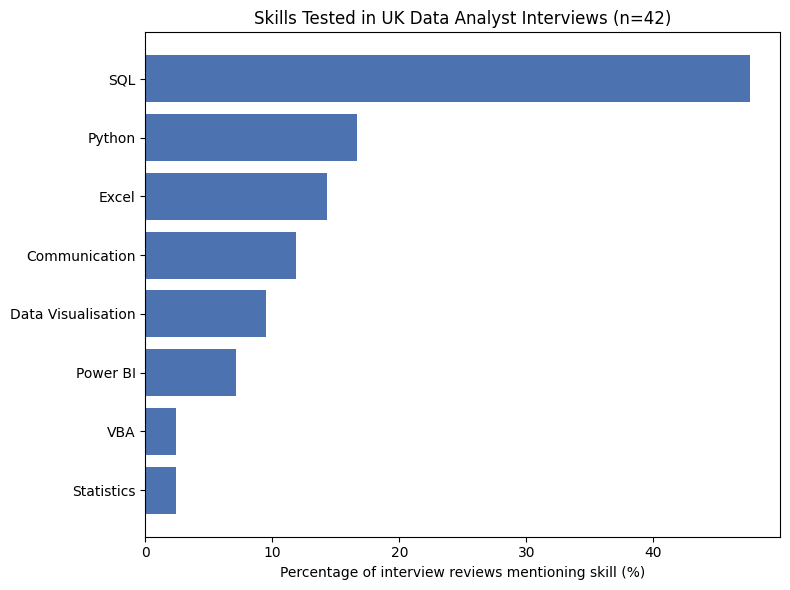

In [23]:
import matplotlib.pyplot as plt

chart_data = skill_reviews_df[skill_reviews_df["count"] > 0]

plt.figure(figsize=(8, 6))
plt.barh(chart_data["skill"], chart_data["percentage"], color="#4C72B0")
plt.xlabel("Percentage of interview reviews mentioning skill (%)")
plt.title("Skills Tested in UK Data Analyst Interviews (n=42)")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("/kaggle/working/outputs/chart1_skills_in_interviews.png", dpi=150)
plt.show()

## Supplementary Data - Salary & Contract Type Analysis

A separate, standalone collection of salary and contract type data for UK 
graduate Data Analyst postings. This is independent from the main 287-row 
dataset used for skill analysis, and is used solely for this salary/contract 
chart.

In [24]:
import requests
import pandas as pd

salary_data = []

search_terms = [
    "graduate data analyst",
    "junior data analyst",
    "data analyst"
]

for term in search_terms:
    for page in range(1, 6):
        url = "https://api.adzuna.com/v1/api/jobs/gb/search/" + str(page)

        params = {
            "app_id": APP_ID,
            "app_key": APP_KEY,
            "what": term,
            "where": "uk",
            "results_per_page": 50
        }

        response = requests.get(url, params=params)

        if response.status_code == 200:
            jobs = response.json()["results"]
            if len(jobs) == 0:
                break
            for job in jobs:
                salary_data.append({
                    "title": job.get("title", ""),
                    "salary_min": job.get("salary_min", None),
                    "salary_max": job.get("salary_max", None),
                    "contract_time": job.get("contract_time", "")
                })

df_salary = pd.DataFrame(salary_data)
df_salary = df_salary.drop_duplicates()
df_salary = df_salary.dropna(subset=["salary_min", "salary_max"])

print(f"Rows with salary data: {len(df_salary)}")
print(df_salary[["salary_min", "salary_max"]].describe())
print()
print("Contract type breakdown:")
print(df_salary["contract_time"].value_counts())

Rows with salary data: 188
          salary_min     salary_max
count     188.000000     188.000000
mean    47821.234149   56227.260745
std     25431.771646   28477.585638
min         0.000000   21070.000000
25%     35000.000000   37627.445000
50%     44256.405000   48518.250000
75%     52163.675000   63014.315000
max    169000.000000  169000.000000

Contract type breakdown:
contract_time
full_time    106
              75
part_time      7
Name: count, dtype: int64


### Filtering to Entry-Level Roles

The initial pull (186 rows) included senior and lead roles, producing 
unrealistic salary figures for a graduate audience (median salary_max ~£48k, 
max £169k). Filtering to titles containing "graduate", "junior", "trainee", 
or "entry" produces a more representative entry-level sample (n=24, reduced 
to n=23 after removing one £0 placeholder value).

In [25]:
entry_keywords = ["graduate", "junior", "trainee", "entry"]
df_salary_entry = df_salary[df_salary["title"].str.lower().apply(lambda t: any(k in t for k in entry_keywords))]

print(f"Entry-level rows: {len(df_salary_entry)}")
print(df_salary_entry[["salary_min", "salary_max"]].describe())

Entry-level rows: 23
         salary_min    salary_max
count     23.000000     23.000000
mean   29909.774783  39379.861739
std     9481.609263  15134.782535
min        0.000000  23333.000000
25%    26500.000000  29491.870000
50%    30000.000000  35000.000000
75%    32830.410000  49715.770000
max    49431.540000  78000.000000


In [26]:
df_salary_entry = df_salary_entry[df_salary_entry["salary_min"] > 0]
print(f"Final rows: {len(df_salary_entry)}")
print(df_salary_entry[["salary_min", "salary_max"]].describe())

Final rows: 22
         salary_min    salary_max
count     22.000000     22.000000
mean   31269.310000  40057.173636
std     7045.978566  15129.957544
min    20000.000000  23333.000000
25%    27239.360000  30000.000000
50%    30000.000000  35000.000000
75%    33915.205000  49857.885000
max    49431.540000  78000.000000


### Chart 2 - Entry-Level Data Analyst Salary Ranges (UK)

Box plot showing the distribution of advertised salary minimums and maximums 
for entry-level (graduate/junior/trainee) UK Data Analyst roles (n=23). 
This is a standalone supplementary dataset, separate from the main 287-row 
postings dataset used for skill analysis.

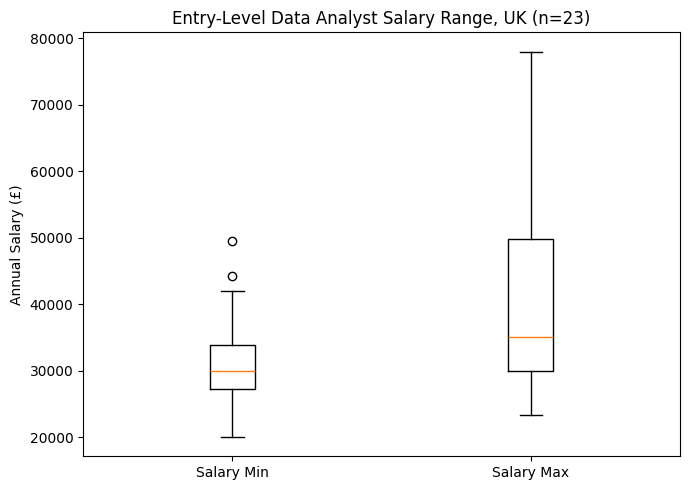

In [27]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [df_salary_entry["salary_min"], df_salary_entry["salary_max"]],
    tick_labels=["Salary Min", "Salary Max"]
)

plt.ylabel("Annual Salary (£)")
plt.title("Entry-Level Data Analyst Salary Range, UK (n=23)")
plt.tight_layout()

plt.savefig("/kaggle/working/outputs/chart2_salary_range.png", dpi=150)
plt.show()

## Chart 3 - The Visibility Gap

The central finding of HireSignal: there is a significant gap between what 
job posting previews show candidates and what is actually tested in 
interviews. This chart compares the percentage of job posting previews 
(n=287) versus interview reviews (n=42) mentioning each of the top three 
skills.

The dramatic gap - particularly for SQL (4.9% visible in postings vs 47.6% 
tested in interviews) - suggests candidates cannot reliably assess technical 
requirements from job postings alone, and must rely on independent research 
(such as this project) to understand what employers actually prioritise.

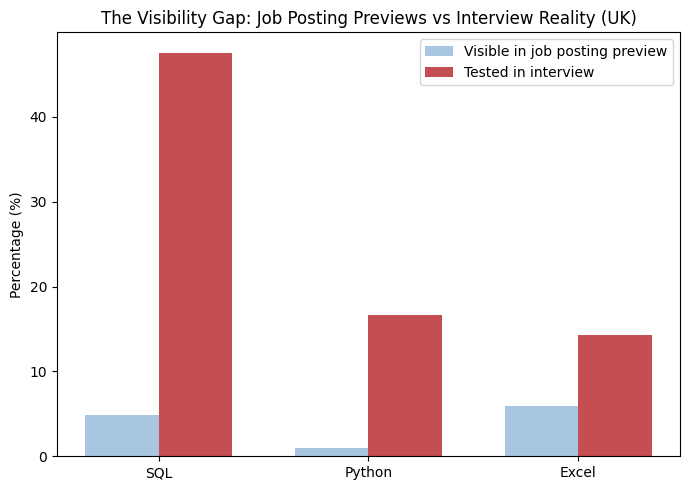

In [28]:
import numpy as np

gap_data = pd.DataFrame({
    "skill": ["SQL", "Python", "Excel"],
    "in_postings": [4.9, 1.0, 5.9],
    "in_interviews": [47.6, 16.7, 14.3]
})

x = np.arange(len(gap_data))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, gap_data["in_postings"], width, label="Visible in job posting preview", color="#A8C5E2")
plt.bar(x + width/2, gap_data["in_interviews"], width, label="Tested in interview", color="#C44E52")

plt.xticks(x, gap_data["skill"])
plt.ylabel("Percentage (%)")
plt.title("The Visibility Gap: Job Posting Previews vs Interview Reality (UK)")
plt.legend()
plt.tight_layout()

plt.savefig("/kaggle/working/outputs/chart3_visibility_gap.png", dpi=150)
plt.show()

## Chart 4 - Sample Composition by Sector

To assess how representative the 42 interview reviews are, each company is 
categorised by sector. This provides transparency about the sample's 
composition and any sector concentration.

In [29]:
df_reviews["company"] = df_reviews["company"].str.strip()

sector_map = {
    "Barclays": "Banking", "HM Revenue and Customs": "Public Sector",
    "Bloomberg": "Finance/Tech", "Lloyds Bank": "Banking",
    "HSBC": "Banking", "Tesco": "Retail", "Amazon": "Tech",
    "Experian": "Finance/Tech", "Hastings Direct": "Insurance",
    "Holland & Barrett": "Retail", "Capital one": "Banking",
    "Wise": "Fintech", "ALDI": "Retail", "Xantura": "Tech/Social Impact",
    "Marks & Spencer": "Retail", "BBC": "Media", "TikTok": "Tech",
    "Capita Bank": "Banking", "Deutsche Bank": "Banking",
    "Network Rail": "Public Sector", "Revolut": "Fintech",
    "Medtronic": "Healthcare", "Ebay": "Tech", "Severn Trent": "Utilities",
    "The AA": "Insurance", "ITV": "Media", "Standard Life plc": "Finance"
}

df_reviews["sector"] = df_reviews["company"].map(sector_map)

print("Unmapped:", df_reviews[df_reviews["sector"].isnull()]["company"].unique())
print("\nSector breakdown:")
print(df_reviews["sector"].value_counts())

Unmapped: []

Sector breakdown:
sector
Banking               11
Retail                 6
Finance/Tech           5
Tech                   4
Public Sector          4
Fintech                3
Insurance              3
Media                  2
Tech/Social Impact     1
Healthcare             1
Utilities              1
Finance                1
Name: count, dtype: int64


### Chart 4 - Sector Distribution

Pie chart showing the proportion of the 42 interview reviews by sector. 
Banking is the most represented sector (26%), followed by Retail (14%), 
Finance/Tech and Tech (12% and 10%), and Public Sector (10%). The sample 
spans 11 sectors across 27 companies, with the remaining sectors 
(Fintech, Insurance, Media, Healthcare, Tech/Social Impact, Utilities, 
Finance) each contributing 2-7%.

This distribution reflects genuine UK graduate hiring patterns - banking 
and retail are consistently among the largest graduate recruiters - while 
also showing the sample is not dominated by a single sector.

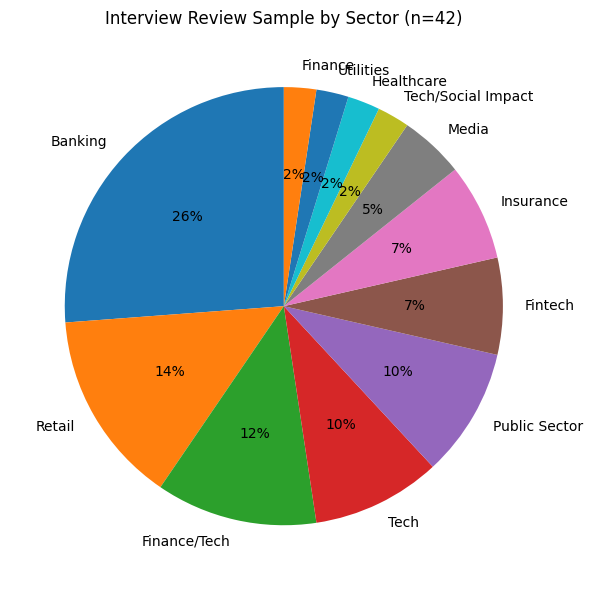

In [30]:
sector_counts = df_reviews["sector"].value_counts()

plt.figure(figsize=(7, 6))
plt.pie(sector_counts, labels=sector_counts.index, autopct="%1.0f%%", startangle=90)
plt.title("Interview Review Sample by Sector (n=42)")
plt.tight_layout()

plt.savefig("/kaggle/working/outputs/chart4_sector_breakdown.png", dpi=150)
plt.show()